In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better visuals
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Step 2: Create fake student data (no Excel file needed)
students = {
    'Roll_No':   [1,   2,   3,   4,   5,   6,   7,   8,   9,   10],
    'Name':      ['Amit', 'Priya', 'Rahul', 'Sneha', 'Vikas', 'Neha', 'Rohan', 'Pooja', 'Karan', 'Anjali'],
    'Gender':    ['M',   'F',   'M',   'F',   'M',   'F',   'M',   'F',   'M',   'F'  ],
    'Branch':    ['CSE','ECE','ME','CSE','ME','CSE','ECE','ME','CSE','ECE'],
    'Semester':  [3,   3,   3,   3,   3,   3,   3,   3,   3,   3],
    'Maths':     [85,  78,  60,  92,  55,  88,  73,  68,  90,  75],
    'Physics':   [75,  82,  58,  88,  50,  90,  70,  65,  85,  70],
    'Chemistry': [70,  85,  62,  80,  48,  92,  72,  60,  82,  68]
}

# Convert to DataFrame (this is our "dataset")
df = pd.DataFrame(students)

# Just to see how the data looks initially
print("Initial data (first few rows):")
display(df.head())

Initial data (first few rows):


,Roll_No,Name,Gender,Branch,Semester,Maths,Physics,Chemistry
0,1,Amit,M,CSE,3,85,75,70
1,2,Priya,F,ECE,3,78,82,85
2,3,Rahul,M,ME,3,60,58,62
3,4,Sneha,F,CSE,3,92,88,80
4,5,Vikas,M,ME,3,55,50,48


In [2]:
# Step 3: Check data quality (missing values, types)
print("Data info (columns and types):")
print(df.info())

# Check if any value is missing (NaN)
print("\nMissing values in each column:")
print(df.isnull().sum())

# Optional: add 1 row with a missing value (for demo)
df_clean = df.copy()
df_clean.loc[len(df_clean)] = [11, 'Raj', 'M', 'CSE', 3, 60, 70, None]  # Chemistry missing

print("\nAfter adding 1 row with missing Chemistry marks:")
display(df_clean.tail())

# Step 4: Handle missing values (here just fill 0, but in real projects use mean/median or drop)
df_clean['Chemistry'] = df_clean['Chemistry'].fillna(0)

print("\nAfter filling missing Chemistry marks with 0:")
display(df_clean.tail())

Data info (columns and types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Roll_No    10 non-null     int64 
 1   Name       10 non-null     object
 2   Gender     10 non-null     object
 3   Branch     10 non-null     object
 4   Semester   10 non-null     int64 
 5   Maths      10 non-null     int64 
 6   Physics    10 non-null     int64 
 7   Chemistry  10 non-null     int64 
dtypes: int64(5), object(3)
memory usage: 772.0+ bytes
None

Missing values in each column:
Roll_No      0
Name         0
Gender       0
Branch       0
Semester     0
Maths        0
Physics      0
Chemistry    0
dtype: int64

After adding 1 row with missing Chemistry marks:


,Roll_No,Name,Gender,Branch,Semester,Maths,Physics,Chemistry
6,7,Rohan,M,ECE,3,73,70,72
7,8,Pooja,F,ME,3,68,65,60
8,9,Karan,M,CSE,3,90,85,82
9,10,Anjali,F,ECE,3,75,70,68
10,11,Raj,M,CSE,3,60,70,None



After filling missing Chemistry marks with 0:


C:\Users\Aditya Srivastav\AppData\Local\Temp\ipykernel_8136\4212380023.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Chemistry'] = df_clean['Chemistry'].fillna(0)


,Roll_No,Name,Gender,Branch,Semester,Maths,Physics,Chemistry
6,7,Rohan,M,ECE,3,73,70,72
7,8,Pooja,F,ME,3,68,65,60
8,9,Karan,M,CSE,3,90,85,82
9,10,Anjali,F,ECE,3,75,70,68
10,11,Raj,M,CSE,3,60,70,0


In [3]:
# Step 5: Create new useful columns from existing data
# 1. Total marks of each student
df_clean['Total'] = df_clean[['Maths','Physics','Chemistry']].sum(axis=1)

# 2. Average marks per student
df_clean['Average'] = df_clean['Total'] / 3

# 3. Pass/Fail status (using threshold: 200+ total = pass)
def get_status(total_marks):
    if total_marks >= 200:
        return 'Pass'
    else:
        return 'Fail'

df_clean['Status'] = df_clean['Total'].apply(get_status)

# 4. Simple grade system (A, B, C, F)
def get_grade(avg_marks):
    if avg_marks >= 90:
        return 'A'
    elif avg_marks >= 75:
        return 'B'
    elif avg_marks >= 60:
        return 'C'
    else:
        return 'F'

df_clean['Grade'] = df_clean['Average'].apply(get_grade)

print("Final enriched data (with Total, Average, Status, Grade):")
display(df_clean[['Name','Total','Average','Status','Grade']])

Final enriched data (with Total, Average, Status, Grade):


,Name,Total,Average,Status,Grade
0,Amit,230,76.666667,Pass,B
1,Priya,245,81.666667,Pass,B
2,Rahul,180,60.000000,Fail,C
3,Sneha,260,86.666667,Pass,B
4,Vikas,153,51.000000,Fail,F
5,Neha,270,90.000000,Pass,A
6,Rohan,215,71.666667,Pass,C
7,Pooja,193,64.333333,Fail,C
8,Karan,257,85.666667,Pass,B
9,Anjali,213,71.000000,Pass,C


In [4]:
# Step 6: Compute basic statistics to understand the data
print("=== Overall statistics (numeric summary) ===")
print("Total students:", len(df_clean))
print("Average total marks:", df_clean['Total'].mean())
print("Maximum total marks (topper):", df_clean['Total'].max())
print("Minimum total marks:", df_clean['Total'].min())
print("Number of students who passed:", sum(df_clean['Status'] == 'Pass'))
print("Number of students who failed:", sum(df_clean['Status'] == 'Fail'))

# Gender-wise average marks
print("\n=== Gender-wise average marks (M vs F) ===")
gender_avg = df_clean.groupby('Gender')['Average'].mean()
print(gender_avg)

# Subject-wise average marks
print("\n=== Subject-wise average marks ===")
subjects = ['Maths', 'Physics', 'Chemistry']
for subject in subjects:
    print(f"{subject}: {df_clean[subject].mean():.2f}")

# Grade distribution (how many A, B, C, F)
print("\n=== Grade distribution (A / B / C / F) ===")
print(df_clean['Grade'].value_counts())

=== Overall statistics (numeric summary) ===
Total students: 11
Average total marks: 213.27272727272728
Maximum total marks (topper): 270
Minimum total marks: 130
Number of students who passed: 7
Number of students who failed: 4

=== Gender-wise average marks (M vs F) ===
Gender
F    78.733333
M    64.722222
Name: Average, dtype: float64

=== Subject-wise average marks ===
Maths: 74.91
Physics: 73.00
Chemistry: 65.36

=== Grade distribution (A / B / C / F) ===
Grade
B    4
C    4
F    2
A    1
Name: count, dtype: int64


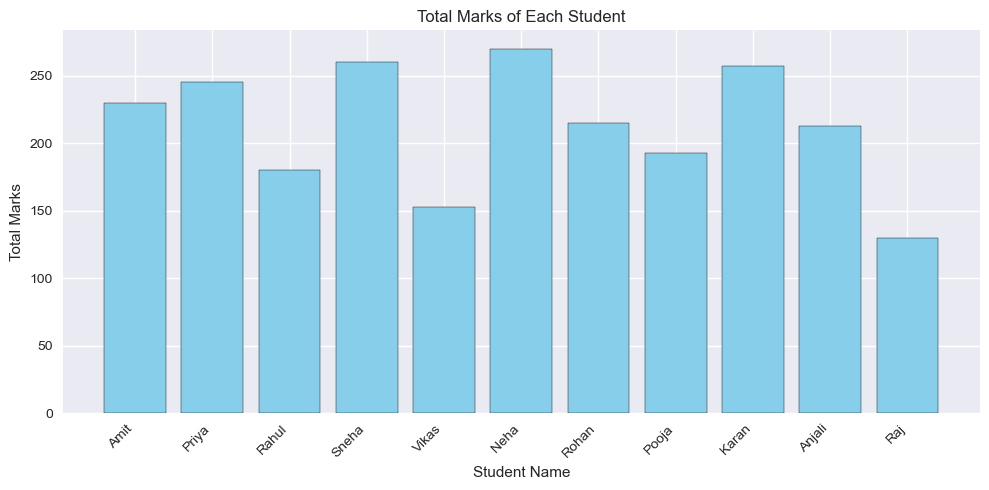

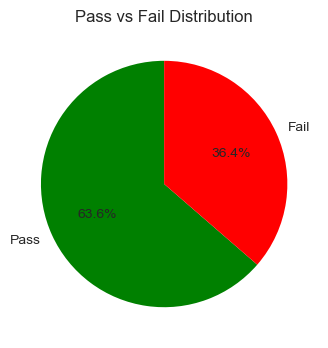

C:\Users\Aditya Srivastav\AppData\Local\Temp\ipykernel_8136\2295425923.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='Gender', y='Average', estimator='mean', ci=None)


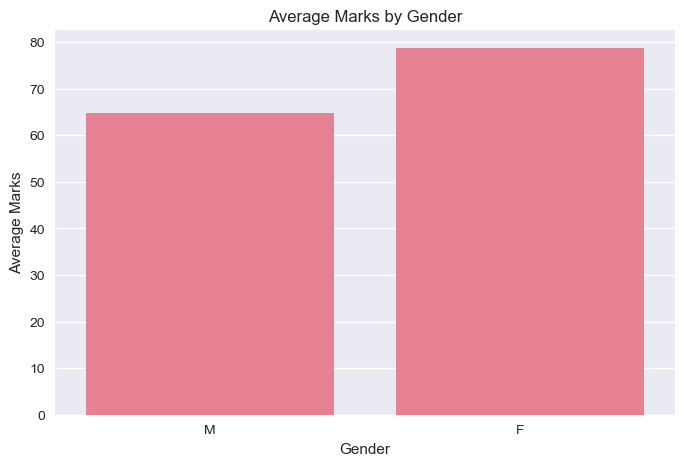

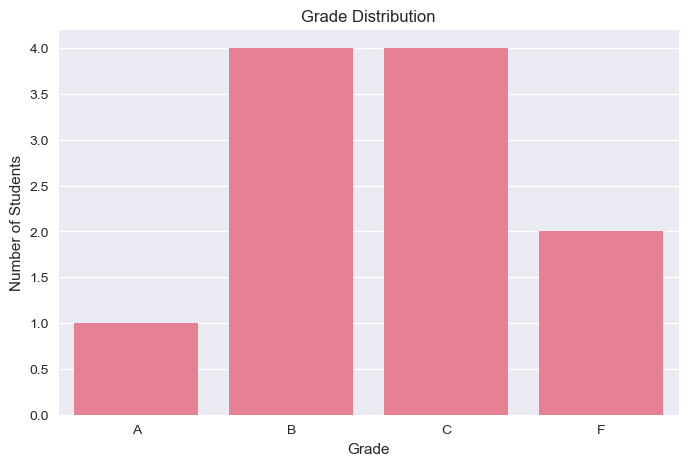

In [5]:
# Step 7: Visualize insights using graphs

# 1. Total marks of each student (bar chart)
plt.figure(figsize=(10, 5))
plt.bar(df_clean['Name'], df_clean['Total'], color='skyblue', edgecolor='black')
plt.title('Total Marks of Each Student')
plt.xlabel('Student Name')
plt.ylabel('Total Marks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Pass/Fail distribution (pie chart)
pass_fail = df_clean['Status'].value_counts()
plt.figure(figsize=(6, 4))
plt.pie(pass_fail, labels=pass_fail.index, autopct='%1.1f%%', startangle=90, colors=['green', 'red'])
plt.title('Pass vs Fail Distribution')
plt.show()

# 3. Average marks by gender (bar chart)
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='Gender', y='Average', estimator='mean', ci=None)
plt.title('Average Marks by Gender')
plt.ylabel('Average Marks')
plt.show()

# 4. Grade distribution (count of each grade)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Grade', order=['A','B','C','F'])
plt.title('Grade Distribution')
plt.ylabel('Number of Students')
plt.show()

In [6]:
# Step 8: Extract key insights in simple sentences (useful for LinkedIn description)

topper_idx = df_clean['Total'].idxmax()
topper = df_clean.loc[topper_idx]

print("=== Key insights from this project ===")
print(f"Topper: {topper['Name']} (Roll No: {topper['Roll_No']}) scored {topper['Total']} marks in total.")
print(f"Overall average total marks: {df_clean['Total'].mean():.1f}")
print(f"Pass/Fail count: {sum(df_clean['Status']=='Pass')} Pass / {sum(df_clean['Status']=='Fail')} Fail")

print("\nFrom this analysis, we can see:")
print("• How many students pass or fail based on a simple threshold (200).")
print("• How average marks compare across genders.")
print("• How subjects contribute to overall performance.")
print("• How grades are distributed (A/B/C/F).")

=== Key insights from this project ===
Topper: Neha (Roll No: 6) scored 270 marks in total.
Overall average total marks: 213.3
Pass/Fail count: 7 Pass / 4 Fail

From this analysis, we can see:
• How many students pass or fail based on a simple threshold (200).
• How average marks compare across genders.
• How subjects contribute to overall performance.
• How grades are distributed (A/B/C/F).
